# Основные сведения о библиотеке OSMnx

## 📚 Общая информация

### 🔹 Что такое OSMnx? {.unnumbered}

**OSMNx** — это библиотека на языке **Python**, предназначенная для **загрузки, анализа и визуализации графов улично-дорожных сетей** из проекта [OpenStreetMap (OSM)](https://www.openstreetmap.org).
Помимо графов улично-дорожных сетей позволяет работать со зданиями, границами районов и другими пространственными объектами.

---

### 🔹 Основные возможности: {.unnumbered}

| Возможность | Описание |
|------------|----------|
| 🗺️ Загрузка графов улиц | Можно загрузить дорожную сеть любого города или района |
| 🧭 Поддержка разных типов дорог | Автомобильные, пешеходные, велосипедные и другие сети |
| 🏙️ Работа с объектами | Загрузка зданий, границ населенных пунктов, водоёмов и других объектов |
| 📐 Анализ графов | Поиск кратчайших путей, расчёт плотности сети, анализ топологии |
| 🎨 Визуализация | Отрисовка карт и маршрутов с помощью Matplotlib |
| 🌐 Интеграция с другими библиотеками | Совместимость с NetworkX, GeoPandas, Folium, Contextily и др. |
| 💾 Сохранение данных | Графы можно сохранить в форматах: GraphML, Shapefile, GeoJSON |

---

### 🔹 Примеры использования: {.unnumbered}

- Загрузка и анализ улично-дорожных сетей
- Анализ ориентации улиц населенных пунктов
- Расчёт маршрутов между точками
- Исследование доступности общественного транспорта
- Образование и научные исследования в области геоинформатики
- Создание прототипов приложений для навигации и логистики

---

### 🔹 Основные функции: {.unnumbered}

| Функция | Назначение |
|--------|-----------|
| `ox.graph_from_place()` | Загружает граф улиц по названию места |
| `ox.graph_from_bbox()` | Загружает граф по координатам прямоугольной области |
| `ox.geometries_from_place()` | Загружает объекты (здания, парки и др.) |
| `ox.plot_graph()` | Рисует граф на карте |
| `ox.shortest_path()` | Находит кратчайший путь между узлами графа |
| `ox.distance.nearest_nodes()` | Находит ближайшие узлы к заданным координатам |
| `ox.save_graphml()` / `ox.save_graph_geopackage()` | Сохраняет граф в файл **GraphML** или **geopackage** |

---

### 🔹 Техническая информация: {.unnumbered}

| Характеристика | Описание |
|----------------|----------|
| Язык программирования | Python |
| Лицензия | MIT License (открытый исходный код) |
| Автор | Geoff Boeing ([https://geoffboeing.com](https://geoffboeing.com)) [@boeing_osmnx_2017; @boeing_resilient_2024] |
| Документация | [https://osmnx.readthedocs.io](https://osmnx.readthedocs.io) |
| Установка | `pip install osmnx` или `conda install -c conda-forge osmnx` |
| Зависимости | NetworkX, GeoPandas, Matplotlib, Requests и др. |

## Основные примеры использования библиотеки osmnx

Рекомендуемая версия `osmnx` для использования примеров: `2.0.1`.

### Загрузка графа дорог по названию города

Версия osmnx: 2.0.1


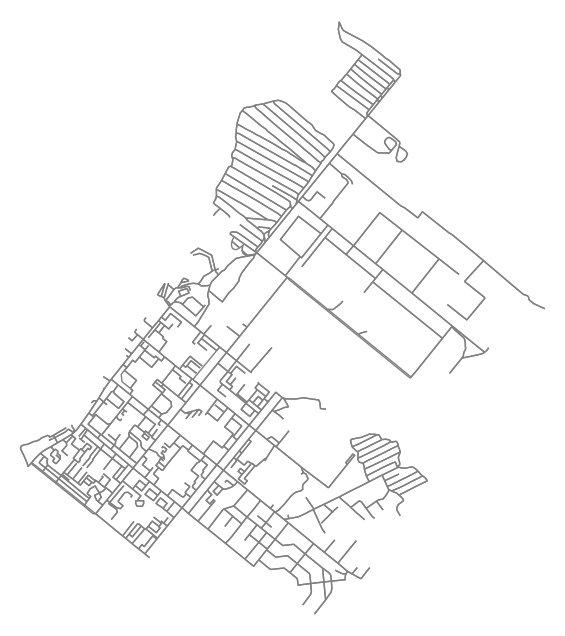

In [1]:
import matplotlib.pyplot as plt
import osmnx as ox
print('Версия osmnx:', ox.__version__)

# Разрешаем выгружать данные частных дорог
ox.settings.default_access = ''

# Загружаем дорожный граф по названию населенного пункта
G = ox.graph_from_place("Сосновоборск, Красноярский край, Россия", network_type="drive_service")

# Визуализируем граф
fig, ax = ox.plot_graph(G, node_size=0, edge_color='gray', bgcolor='white')

:::{.callout-note}

По умолчанию osmnx фильтрует дороги с пометкой `private` (частные). Для подразделений пожарной охраны это несущественно, т.к. они могут следовать в том числе и по частной территории. Поэтому при выгрузке ГДС рекомендуется использовать код:

    ox.settings.default_access = ''

:::

### Загрузка полигона границ населенного пункта

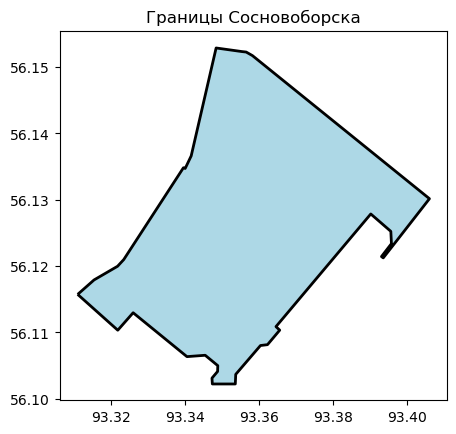

In [3]:
# Загружаем полигон границы Сосновоборска
boundary = ox.geocode_to_gdf("Сосновоборск, Красноярский край, Россия")

# Визуализируем полигон
ax = boundary.plot(facecolor='lightblue', edgecolor='black', linewidth=2)
ax.set_title("Границы Сосновоборска")
plt.show()

### Загрузка графа дорог в пределах полигона границ

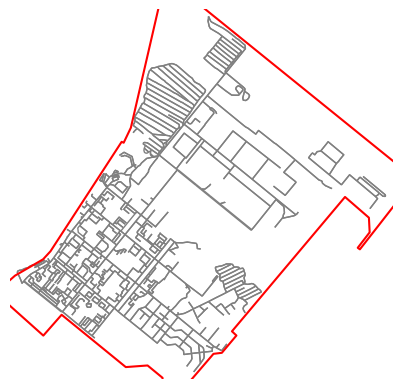

In [4]:
# Используем ранее загруженный полигон для фильтрации графа
G = ox.graph_from_polygon(boundary.union_all(), network_type="drive_service", retain_all=True)

# Визуализируем
ax = boundary.boundary.plot(color='r')
ox.plot_graph(G, ax=ax, node_size=0, edge_color='grey', bgcolor='white')
plt.show()

### Загрузка графа дорог в пределах полигона с буфером 1000 м

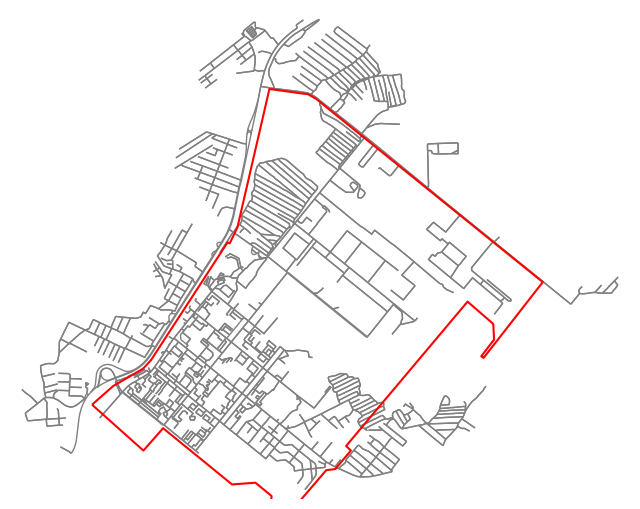

In [14]:
# Создаем буфер вокруг полигона (в метрах)
buffered_polygon = ox.projection.project_gdf(boundary).copy()
buffered_polygon.geometry = buffered_polygon.geometry.buffer(1000)
buffered_polygon = ox.projection.project_gdf(buffered_polygon, to_latlong=True)

# Загружаем граф с учетом буфера
G = ox.graph_from_polygon(buffered_polygon.union_all(), network_type="drive_service")

# Рисуем результат
fig, ax = ox.plot_graph(G, node_size=0, edge_color='grey', bgcolor='white', close=False, show=False)
boundary.boundary.plot(color='r', ax=ax)
plt.show()

### Упрощение ГДС

Упрощение графа заключается в удалении промежуточных узлов, не влияющих на результаты расчета. Это позволяет существенно (до 4 раз сократить размер графа), что в свою очередь положительно сказывается на скорости моделирования.

Функции выгрузки графа, такие как `ox.graph_from_polygon` по умолчанию выгружают ГДС упрощенный граф. Установка аргумента `simplify=False` позволяет выгрузить неупрощенный граф:

    G = ox.graph_from_place("Сосновоборск, Красноярский край, Россия",
        network_type="drive_service",
        simplify=False)

Установку скоростного режима рекомендуется выполнять применительно к неупрощенному ГДС, после чего можно выполнить процедуру упрощения:

    G = ox.simplification.simplify_graph(G)

In [15]:
G = ox.graph_from_place("Сосновоборск, Красноярский край, Россия",
        network_type="drive_service",
        simplify=False)
print('Неупрощенный граф:  Количество узлов:', len(G.nodes()), 'Количество ребер:', len(G.edges()))
G = ox.simplification.simplify_graph(G)
print('Упрощенный граф:    Количество узлов:', len(G.nodes()), 'Количество ребер:', len(G.edges()))

Неупрощенный граф:  Количество узлов: 1904 Количество ребер: 4167
Упрощенный граф:    Количество узлов: 651 Количество ребер: 1688


### Установка скоростей следования для дорог

In [7]:
# Загрузка графа. Для наглядности граф не упрощается.
G = ox.graph_from_place("Сосновоборск, Красноярский край, Россия", network_type="drive_service", simplify=False)

# Добавляем скорость к каждому ребру графа
G = ox.add_edge_speeds(G)

# Теперь можно рассчитать время проезда
G = ox.add_edge_travel_times(G)

# Оцениваем присвоенные параметры
g_edges = ox.graph_to_gdfs(G, nodes=False)
print(g_edges.groupby('highway')[['speed_kph', 'travel_time']].mean())
g_edges[['highway', 'speed_kph', 'length', 'travel_time']].head()

              speed_kph  travel_time
highway                             
residential   41.666667     6.559310
secondary     50.000000     4.551353
service       35.000000     4.855711
tertiary      40.000000     5.237655
unclassified  41.666667     6.842930


highway  speed_kph      length  travel_time
u         v          key                                                  
360828220 2468412831 0    unclassified  41.666667   12.279499     1.060949
426923792 6222357764 0       secondary  50.000000  540.015188    38.881094
          5574296097 0       secondary  50.000000   20.609225     1.483864
          2468412836 0    unclassified  41.666667   22.369596     1.932733
426923793 1296599760 0       secondary  50.000000   11.611146     0.836002

* `highway` - класс дороги
* `speed_kph` - Скорости следования, км/ч
* `travel_time` - Время следования по участку дороги, сек
* `length` - Длина участка дороги, м

:::{.callout-important}

Встроенная функция `osmnx.add_edge_travel_times()` рассчитывает для `travel_time` время следования в **секундах**!

Функционал же `genesis` использует время в минутах. Поэтому в расчетах с использованием `genesis` необходимо использовать функцию `set_graph_travel_times` модуля `graphs.speeds`. Подробнее об этом см. в соответствующем разделе руководства.

:::

### Расчёт кратчайшего маршрута и времени следования между точками

Время следования: 135.3555412018432 сек.
Длина маршрута:   1858.2466468504206 м


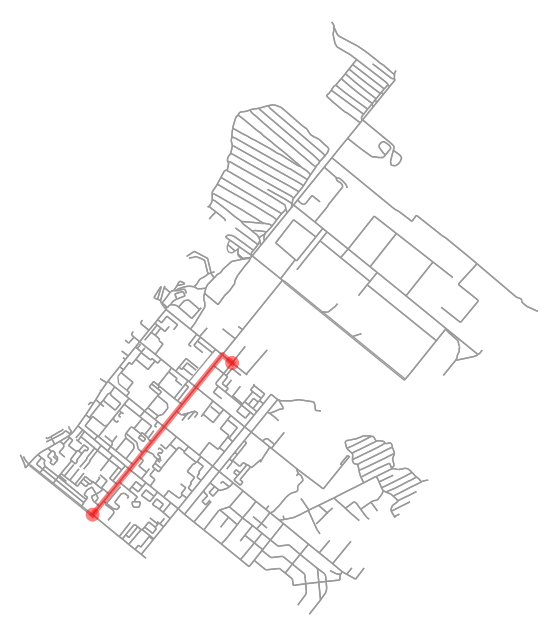

In [8]:
# Выберем два случайных узла из графа
origin, destination = list(G.nodes())[2], list(G.nodes())[10]

# Найдём маршрут скорейший по времени прибытия
route = ox.shortest_path(G, origin, destination, weight='travel_time')

# Печатаем время следования по маршруту
route_gdf = ox.routing.route_to_gdf(G, route, weight='travel_time')
print('Время следования:', route_gdf['travel_time'].sum(), 'сек.')
print('Длина маршрута:  ', route_gdf['length'].sum(), 'м')

# Рисуем маршрут по длине
fig, ax = ox.plot_graph_route(G, route, node_size=0, bgcolor='white')

### Загрузка данных о зданиях в пределах полигона границ населенного пункта

Набор зданий: (603, 8)


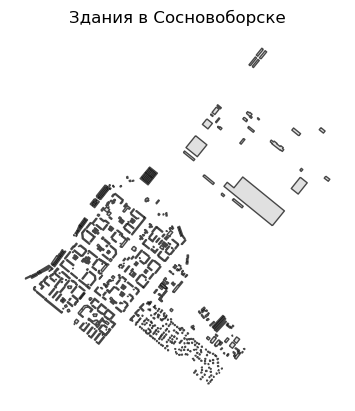

In [9]:
# Тег OSM для зданий
tags = {'building': True}

# Словарь полей, которые следует оставить в наборе. Если не использовать, будут сохранены излишние данные
fields = [
  'name',
  'amenity',
  'building',
  'addr:street',
  'addr:housenumber',
  'building:levels',
  'building:flats',
  # 'rooms',
  'geometry',
]

# Загрузка набора данных  из OSM
buildings = ox.features_from_polygon(boundary.union_all(), tags)
# Оставляем только данные с геометрией Полигон или Мультиполигон
buildings = buildings[buildings.geometry.apply(lambda x: x.geom_type).isin(['Polygon', 'MultiPolygon'])]
# Оставляем только заданные поля
buildings = buildings[fields]
# Удаляем индекс по типу элемента
buildings = buildings.reset_index().drop('element', axis=1)
# Устанавливаем индекс 'osmid'
buildings = buildings.set_index('id')

# Проверяем количество записей и полей
print('Набор зданий:', buildings.shape)

# Рисуем здания
ax = buildings.plot(edgecolor='black', facecolor='lightgray', alpha=0.7)
ax.set_title("Здания в Сосновоборске")
ax.set_axis_off()
plt.show()

### Сопоставление зданий с ближайшими вершинами графа дорожной сети

Данная операция необходима для расчета скорейшего маршрута между зданиями (по узлам ГДС)

In [10]:
# Получаем центроиды зданий
points = ox.projection.project_gdf(buildings).centroid

# Находим ближайшие узлы графа
nodes = ox.distance.nearest_nodes(ox.project_graph(G), X=points.x, Y=points.y)

# Сохраняем в DataFrame
buildings['nearest_node'] = nodes

# Выводим первые строки
buildings[['addr:street', 'addr:housenumber', 'nearest_node']].sample(5)

,addr:street,addr:housenumber,nearest_node
id,,,
448863582,NaN,NaN,1555148571
493159193,Садовый переулок,6,5574240376
493159208,Центральный переулок,7,2586140423
493159203,Дружный переулок,20,4850965300
114547734,улица Труда,15,1548375965


:::{.callout-important}

Настоятельно рекомендуется проецировать наборы пространственных данных в единую систему координат (СК).

В `osmnx` для этой цели используются функции:

- `ox.projection.project_gdf` - для проецирования наборов пространственных данных (`GeoDataFrame`)
- `ox.project_graph` - для проецирования графов.

Более подробно о проецировании см. документацию: https://osmnx.readthedocs.io/en/stable/user-reference.html#module-osmnx.projection

:::

### Сохранение графа дорог в GraphML и GeoPackage

In [11]:
# Сохраняем в формате GraphML
ox.save_graphml(G, filepath="data/graph_sosnovoborsk.ml")

# Сохраняем в формате GeoPackage
ox.save_graph_geopackage(G, filepath="data/graph_sosnovoborsk.gpkg")

### Загрузка графа дорог из GraphML

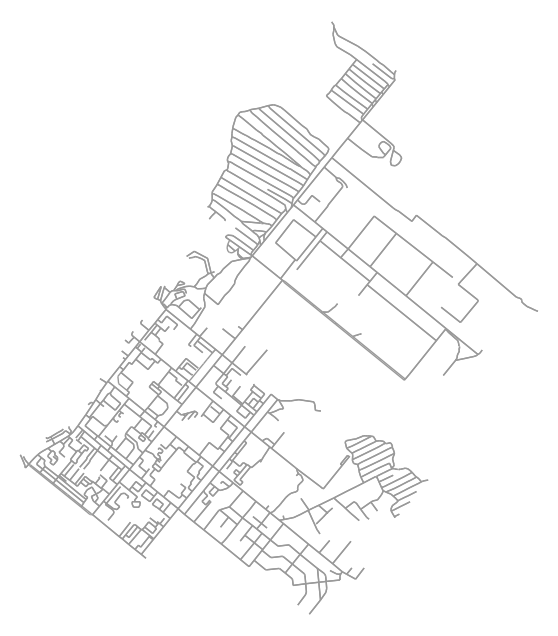

In [12]:
# Загружаем граф обратно из файла
G = ox.load_graphml(filepath="data/graph_sosnovoborsk.ml")

# Рисуем загруженный граф
fig, ax = ox.plot_graph(G, node_size=0, bgcolor='white');

### Сохранение полигона границ и данных о зданиях в файлы GeoPackage

Как правило для последующей работы требуется сохранять данные о зданиях и границах в формат пригодный для работы в приложении QGIS. Для этого можно использовать описанный код.

In [13]:
# Сохраняем границы в GeoPackage
boundary.to_file("data/boundary_sosnovoborsk.gpkg", driver="GPKG")

# Сохраняем здания в тот же или новый GeoPackage
buildings.to_file("data/buildings_sosnovoborsk.gpkg", driver="GPKG")